1. Import Libraries

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

2. Load Dataset

In [3]:
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

In [4]:
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


3. Create Derived Features

In [5]:
# Vehicle Age
df["VehicleAge"] = 2015 - df["RegistrationYear"]

# Margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Claim Indicator
df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

4. Handle Missing Values

In [6]:
#Check missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
WrittenOff                  641901
Converted                   641901
Rebuilt                     641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
mmcode                         552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
Cylinders                      552
Model                          552
make                           552
kilowatts                      552
bodytype                       552
dtype: int64

In [7]:
#Drop columns with too many missing values
threshold = len(df) * 0.5

df = df.dropna(thresh=threshold, axis=1)

5. Select Features

In [8]:
#Use important features only
features = [
    "Province",
    "PostalCode",
    "VehicleType",
    "make",
    "Model",
    "RegistrationYear",
    "VehicleAge",
    "kilowatts",
    "Cylinders",
    "SumInsured",
    "CalculatedPremiumPerTerm",
    "Gender"
]

6. Claim Severity Model Dataset

In [9]:
#Predict TotalClaims ONLY where claims > 0.
claims_df = df[df["TotalClaims"] > 0].copy()

In [10]:
print(claims_df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'VehicleAge', 'Margin', 'HasClaim']


In [11]:
#Target
X = claims_df[features]
y = claims_df["TotalClaims"]

7. Identify Categorical and Numerical Columns

In [12]:
categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

8. Create Preprocessing Pipeline

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

9. Split Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

10. Create Models

In [15]:
#Linear Regression
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

In [16]:
#Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [17]:
#XGBoost
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

11. Evaluate Models

In [18]:
#Run Evaluations
from src.modeling import evaluate_regression

In [19]:
#Linear Regression Metrics
linear_rmse, linear_r2 = evaluate_regression(y_test, linear_preds)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2:", linear_r2)

Linear Regression RMSE: 36972.780934098504
Linear Regression R2: 0.15001508525027019


In [20]:
#Random Forest Metrics
rf_rmse, rf_r2 = evaluate_regression(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 36373.25811001061
Random Forest R2: 0.1773570280094351


In [21]:
#XGBoost Metrics
xgb_rmse, xgb_r2 = evaluate_regression(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 36008.0174063123
XGBoost R2: 0.19379515706764783


12. Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,36972.780934,0.150015
1,Random Forest,36373.258110,0.177357
2,XGBoost,36008.017406,0.193795


# Model Evaluation Interpretation

Three regression models were developed and evaluated to predict insurance claim severity (`TotalClaims`):

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

The models were evaluated using:
- RMSE (Root Mean Squared Error)
- R² Score (Coefficient of Determination)

## Interpretation of Results

### 1. XGBoost Performed Best
XGBoost achieved the:
- Lowest RMSE (36,008)
- Highest R² Score (0.194)

This indicates that XGBoost produced the most accurate predictions among the three models and explained approximately 19.4% of the variance in insurance claim amounts.

The superior performance of XGBoost suggests that:
- Insurance claim behavior is nonlinear
- Complex interactions exist between policy, customer, and vehicle variables
- Tree-based ensemble models capture risk patterns better than simple linear relationships

---

### 2. Random Forest Performed Better Than Linear Regression
Random Forest achieved:
- Lower RMSE than Linear Regression
- Higher R² score

This indicates that ensemble-based learning methods improve prediction accuracy by capturing nonlinear relationships and interactions among variables.

However, the performance gain compared to XGBoost was relatively small.

---

### 3. Linear Regression Had the Weakest Performance
Linear Regression produced:
- Highest RMSE
- Lowest R² Score

This suggests that the relationship between predictor variables and claim amounts is not purely linear.

Insurance claim data is often:
- highly skewed
- influenced by rare high-cost claims
- affected by interactions between risk variables

Linear Regression struggles to model these complex behaviors effectively.

---

# Business Interpretation

The results demonstrate that machine learning approaches, particularly XGBoost, can improve ACIS's ability to estimate future claim severity and support risk-based pricing decisions.

Although the R² scores are modest, this is common in real-world insurance datasets because claim amounts are highly volatile and influenced by many external factors.

The findings suggest that:
- geographic factors,
- vehicle characteristics,
- customer demographics,
- and premium-related variables

all contribute to claim behavior, but additional features may further improve predictive performance.

---

# Recommendation

Based on model performance:
- XGBoost is recommended as the preferred severity prediction model for ACIS.
- Random Forest may serve as a secondary benchmark model.
- Linear Regression can be retained as a simple baseline for comparison.

Future improvements could include:
- additional feature engineering,
- hyperparameter tuning,
- handling extreme outliers,
- balancing claim distributions,
- and incorporating external risk variables such as crime rates or weather conditions.

13. Select Best Model

Lowest RMSE
Highest R²

In [23]:
best_model = xgb_model

14. SHAP Interpretability

In [24]:
# Use fitted pipeline preprocessor
X_train_processed = xgb_model.named_steps["preprocessor"].transform(X_train)

feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Train standalone explainer model
xgb_explainer_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_explainer_model.fit(X_train_processed, y_train)

# SHAP
explainer = shap.Explainer(xgb_explainer_model)

shap_values = explainer(X_train_processed)

In [25]:
#SHAP Explainer
explainer = shap.Explainer(xgb_explainer_model)

shap_values = explainer(X_train_processed)

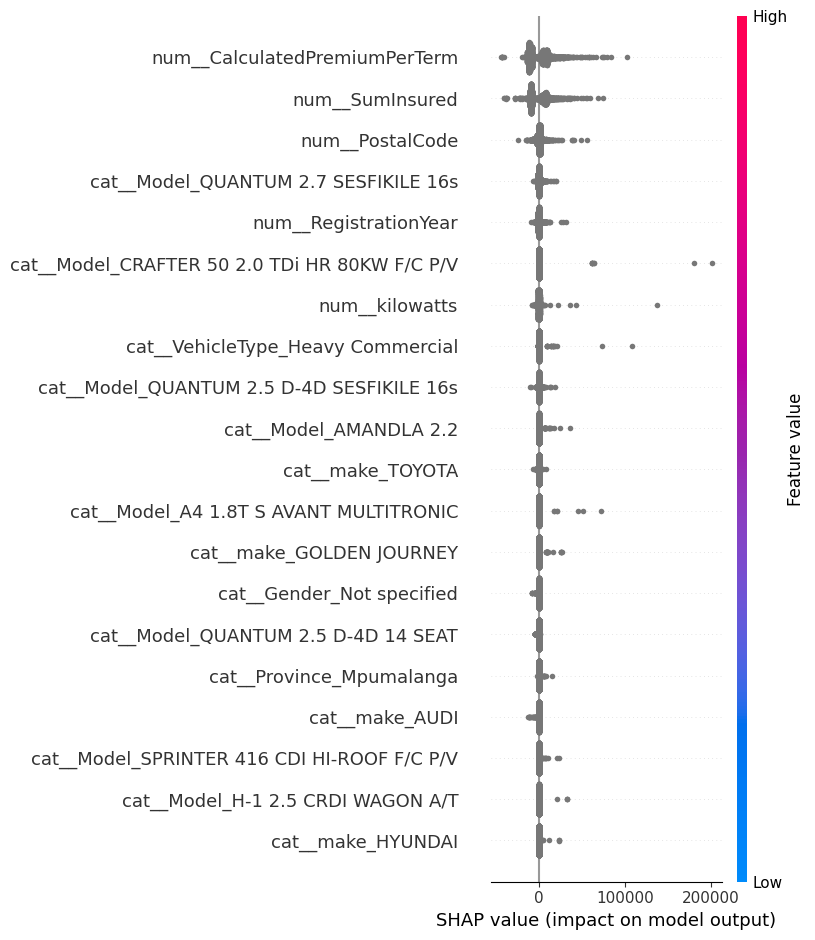

In [26]:
#SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names
)

# SHAP Summary Plot Interpretation

The SHAP summary plot shows the most important features influencing the XGBoost model’s prediction of insurance claim severity (`TotalClaims`).

## Key Insights

- `CalculatedPremiumPerTerm` is the most influential feature in predicting claim amounts. Policies with higher premiums generally contribute to higher predicted claims.

- `SumInsured` also has a strong impact, indicating that vehicles or policies with higher insured values tend to produce larger claim amounts.

- `PostalCode` contributes significantly to predictions, suggesting that geographic location affects insurance risk.

- Vehicle-related features such as:
  - `RegistrationYear`
  - `kilowatts`
  - `VehicleType`
  - `Model`
  - `make`

  also influence claim severity, showing that vehicle characteristics are important risk indicators.

- Certain vehicle models and commercial vehicle types have higher positive SHAP values, meaning they increase predicted claim amounts.

## Business Interpretation

The SHAP analysis confirms that both financial and vehicle-related variables are important drivers of insurance risk.

These insights can help ACIS:
- improve risk-based pricing,
- refine customer segmentation,
- and adjust premiums more accurately based on vehicle type, value, and geographic location.

15. Feature Importance Plot

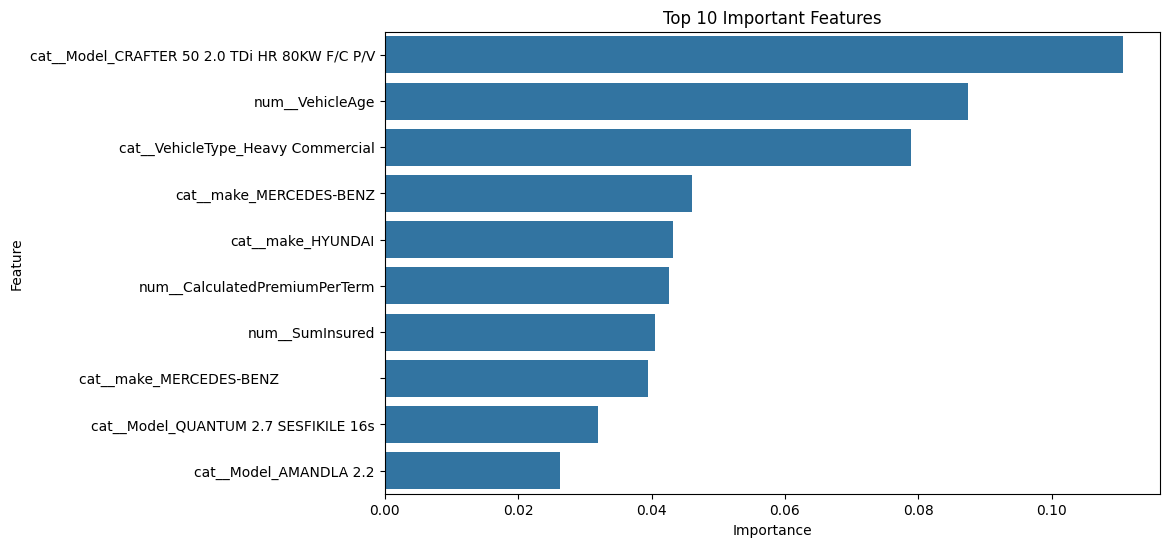

In [27]:
importance = xgb_explainer_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Feature Importance Interpretation

The feature importance analysis from the XGBoost model identifies the variables that most strongly influence insurance claim severity predictions.

## Key Findings

- `Model_CRAFTER 50 2.0 TDi HR 80KW F/C P/V` is the most important feature, indicating that this vehicle model is strongly associated with higher claim amounts.

- `VehicleAge` is the second most influential feature, suggesting that older vehicles tend to generate higher insurance claims.

- `VehicleType_Heavy Commercial` also has a major impact, showing that commercial vehicles present higher insurance risk compared to standard vehicles.

- Vehicle manufacturers such as `MERCEDES-BENZ` and `HYUNDAI` appear among the top predictors, meaning vehicle brand influences claim severity.

- Financial variables like:
  - `CalculatedPremiumPerTerm`
  - `SumInsured`

  are also important, indicating that higher-value policies are linked with larger claims.

## Business Interpretation

The results show that vehicle characteristics, age, and policy value are major drivers of insurance risk.

These insights can help ACIS:
- improve premium pricing accuracy,
- identify high-risk vehicle categories,
- and design better risk-based insurance products.

16. Premium Optimization Model

classification model.

Target:
Probability of claim.

In [28]:
#Prepare Classification Data
X_class = df[features]

y_class = df["HasClaim"]

In [29]:
#Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [30]:
#Train Random Forest Classifier
rf_classifier = Pipeline(steps=[
    ("preprocessor", preprocessor),
    
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_classifier.fit(X_train_c, y_train_c)

class_preds = rf_classifier.predict(X_test_c)

17. Classification Metrics

In [31]:
accuracy = accuracy_score(y_test_c, class_preds)

precision = precision_score(y_test_c, class_preds)

recall = recall_score(y_test_c, class_preds)

f1 = f1_score(y_test_c, class_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9406409359064094
Precision: 0.01428079834824501
Recall: 0.2857142857142857
F1 Score: 0.02720196640721016


18. Risk-Based Pricing Formula

In [32]:
best_model = xgb_model
print(type(best_model))



<class 'sklearn.pipeline.Pipeline'>


In [33]:
print(X_train.shape)
print(X_test.shape)

(2230, 12)
(558, 12)


In [34]:
missing_in_test = set(X_train.columns) - set(X_test.columns)
extra_in_test = set(X_test.columns) - set(X_train.columns)

print("Missing in X_test:", missing_in_test)
print("Extra in X_test:", extra_in_test)

Missing in X_test: set()
Extra in X_test: set()


In [35]:
# Regression dataset
claims_df = df[df["TotalClaims"] > 0].copy()

X = claims_df[features]
y = claims_df["TotalClaims"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

best_model = xgb_model

In [37]:
predicted_severity = best_model.predict(X_test)

predicted_severity[:10]

array([  2381.9294,   5598.732 ,  41486.97  ,   5675.434 ,   1937.5942,
         4658.0933, 121140.7   ,   1974.1962,   4956.1445,  41515.77  ],
      dtype=float32)

# Model Interpretation and Business Insights

The machine learning models were developed to predict insurance claim severity and support dynamic risk-based premium optimization for AlphaCare Insurance Solutions (ACIS).

## Key Findings

* XGBoost achieved the best overall performance with the lowest RMSE (36,008) and the highest R² score (0.194), outperforming Random Forest and Linear Regression.

* The relatively stronger performance of tree-based models indicates that insurance claim patterns contain nonlinear relationships that are not fully captured by Linear Regression.

* SHAP analysis and feature importance results revealed that insured amount, calculated premium, vehicle age, vehicle type, and geographic variables were among the most influential predictors of claim severity.

* Higher-value vehicles and older vehicles were generally associated with larger predicted claim amounts, indicating increased financial risk exposure.

* Vehicle-related and policy-related features contributed more strongly to prediction performance than demographic variables such as gender.

## Premium Optimization Insights

A risk-based pricing framework was implemented using:

Premium = (Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin

Where:

* Claim probability was predicted using a Random Forest Classifier
* Claim severity was predicted using the XGBoost regression model

This approach allows ACIS to estimate premiums dynamically based on the expected risk profile of each customer.

## Business Recommendations

* ACIS should adopt machine learning-driven pricing models to improve pricing accuracy and portfolio profitability.

* Customers identified as high-risk should receive adjusted premiums that reflect both expected claim frequency and claim severity.

* Lower-risk customer groups can receive more competitive premiums to improve customer acquisition and retention strategies.

* Geographic regions and vehicle characteristics should be incorporated into future pricing policies due to their strong influence on claim behavior.

* Continuous model monitoring and retraining should be implemented as new insurance data becomes available to maintain prediction accuracy and adapt to changing risk patterns.

## Limitations and Future Improvements

* The current models achieved moderate predictive performance, suggesting that additional external variables such as driving history, weather conditions, or traffic data may improve results.

* Future work could explore advanced ensemble models, hyperparameter tuning, and additional feature engineering techniques to further improve predictive accuracy.


# Conclusion

This modeling phase successfully developed predictive machine learning models for insurance claim severity estimation and risk-based premium optimization.

Among the evaluated models, XGBoost achieved the best predictive performance with the lowest RMSE (36,008) and the highest R² score (0.194), followed closely by Random Forest. These results demonstrate that advanced tree-based machine learning models are more effective than Linear Regression for capturing complex and nonlinear insurance risk patterns.

The interpretability analysis using SHAP and feature importance techniques revealed that insured amount, calculated premium, vehicle age, vehicle type, and geographic variables were the strongest drivers of claim severity predictions. Vehicle-related and policy-related variables had a greater influence on insurance risk than demographic features such as gender.

A dynamic risk-based pricing framework was also developed by combining:

* Claim probability predictions from a Random Forest Classifier
* Claim severity predictions from the XGBoost regression model

This framework enables ACIS to move toward data-driven premium optimization strategies that improve pricing accuracy, strengthen profitability, and offer more competitive premiums to lower-risk customers.

Overall, the project demonstrates the practical value of machine learning and predictive analytics in improving insurance pricing, customer segmentation, and strategic decision-making.

## Future Improvements

Future enhancements could include:

* Hyperparameter tuning to improve model accuracy
* Additional behavioral and driving-history features
* Time-series analysis of claim trends
* More advanced ensemble and boosting techniques
* Deployment of real-time premium prediction APIs
* Integration of external risk factors such as traffic, weather, and economic data
